In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv(r"C:\Users\ahmed\Documents\Data Science and AI(LUX)\PPORTFOLIO PROJECTS\INVENTORY FORECASTING\CSV\CLEAN\feature_engineered_sales.csv")
pd.set_option('display.max_columns',None)
df.head()

,product_id,product_name_x,category_x,units_sold,unit_price_x,promotion_flag,stock_level_end_of_day,stockout_flag,date,product_name_y,category_y,unit_cost,unit_price_y,lead_time_days,safety_stock_days,day_of_week,is_weekend,Month,Quarter,is_festive,day_of_year,Revenue,rolling_7d_avg,rolling_28d_avg,previous_day_sale,previous_week_sale,days_since_last_promo
0,SKU001,Soda 500ml,Beverages,29,154.61,False,365.9,False,2024-01-01,Soda 500ml,Beverages,126.94,154.61,5,4,Monday,False,1,1,False,1,4483.69,29.0,29.0,NaN,NaN,0
1,SKU001,Soda 500ml,Beverages,27,154.61,False,338.9,False,2024-01-02,Soda 500ml,Beverages,126.94,154.61,5,4,Tuesday,False,1,1,False,2,4174.47,28.0,28.0,29.0,NaN,0
2,SKU001,Soda 500ml,Beverages,25,154.61,False,313.9,False,2024-01-03,Soda 500ml,Beverages,126.94,154.61,5,4,Wednesday,False,1,1,False,3,3865.25,27.0,27.0,27.0,NaN,0
3,SKU001,Soda 500ml,Beverages,33,154.61,True,280.9,False,2024-01-04,Soda 500ml,Beverages,126.94,154.61,5,4,Thursday,False,1,1,False,4,5102.13,28.5,28.5,25.0,NaN,0
4,SKU001,Soda 500ml,Beverages,26,154.61,False,254.9,False,2024-01-05,Soda 500ml,Beverages,126.94,154.61,5,4,Friday,False,1,1,False,5,4019.86,28.0,28.0,33.0,NaN,0


*7 day rolling average for daily_sales**

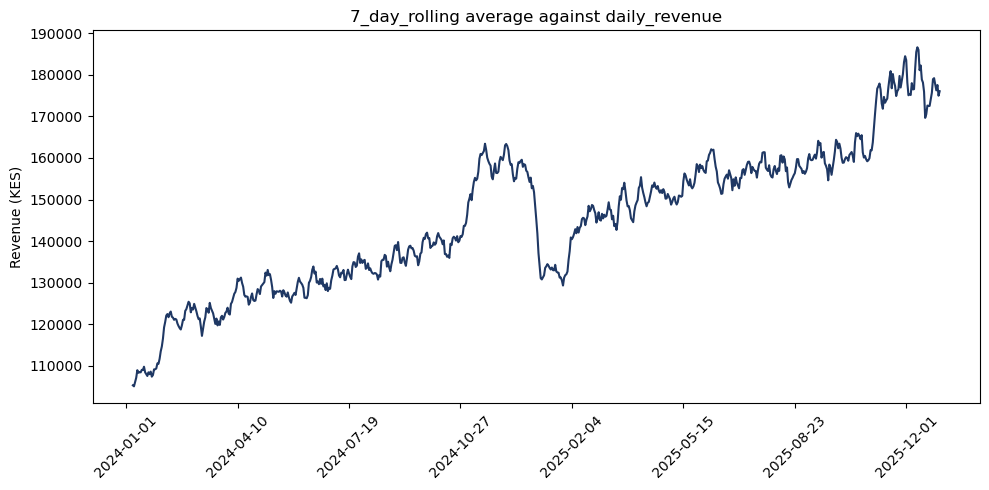

In [3]:

daily_revenue = df.groupby("date")['Revenue'].sum()

fig, ax = plt.subplots(figsize= (10,5))
daily_revenue.rolling(7).mean().plot(ax=ax, color ="#1F3864")
ax.set_title('7_day_rolling average against daily_revenue')
ax.set_ylabel('Revenue (KES)')
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig("revenue_trend.png")
# plt.close(fig)

**Weekly seasonality**

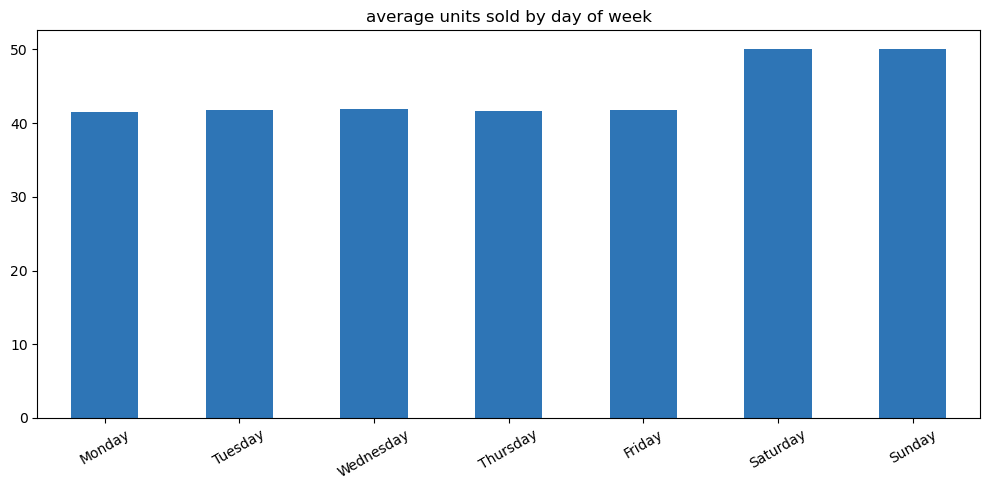

In [4]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_day_of_week = df.groupby('day_of_week')['units_sold'].mean().reindex(dow_order)
fig, ax = plt.subplots(figsize = (10,5))
by_day_of_week.plot(kind = 'bar', ax=ax, color="#2E75B6")
ax.set_title("average units sold by day of week")
ax.set_ylabel("")
ax.set_xlabel("")
plt.xticks(rotation = 30)
fig.tight_layout()
fig.savefig("day_of_week_sales")


**Monthly seasonality**

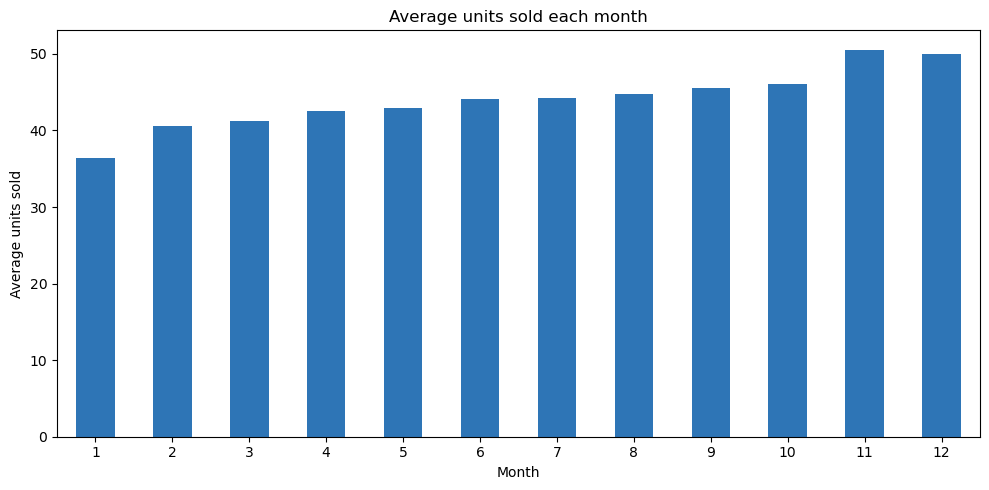

In [5]:
month_order = [1,2,3,4,5,6,7,8,9,1,11,12]
x = df.groupby('Month')['units_sold'].mean()
fig,ax = plt.subplots(figsize = (10,5))
x.plot(kind='bar',ax=ax, color="#2E75B6")
ax.set_title('Average units sold each month')
ax.set_ylabel("Average units sold")
ax.set_xlabel("Month")
plt.xticks(rotation = 0)
fig.tight_layout()
fig.savefig("Average_monthly_sales.png", dpi = 200)


**Top/Bottom products by Revenue**

In [6]:
from matplotlib.ticker import FormatStrFormatter

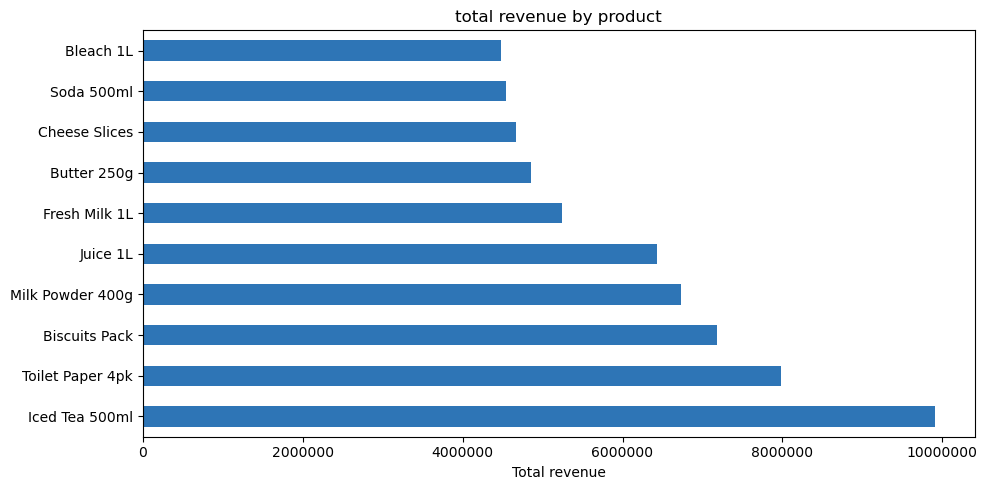

In [7]:
x=df.groupby('product_name_y')['Revenue'].sum()
by_product = x.sort_values(ascending=False)

top10=by_product.head(10)
bottom10= by_product.tail(10)

fig,ax = plt.subplots(figsize=(10,5))
top10.plot(kind='barh',ax=ax, color="#2E75B6")
ax.set_title('total revenue by product')
ax.set_ylabel('')
ax.set_xlabel('Total revenue')
ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xticks(rotation = 0)
fig.tight_layout()
fig.savefig('Most revenue generating products.png')

**Stockout by category**

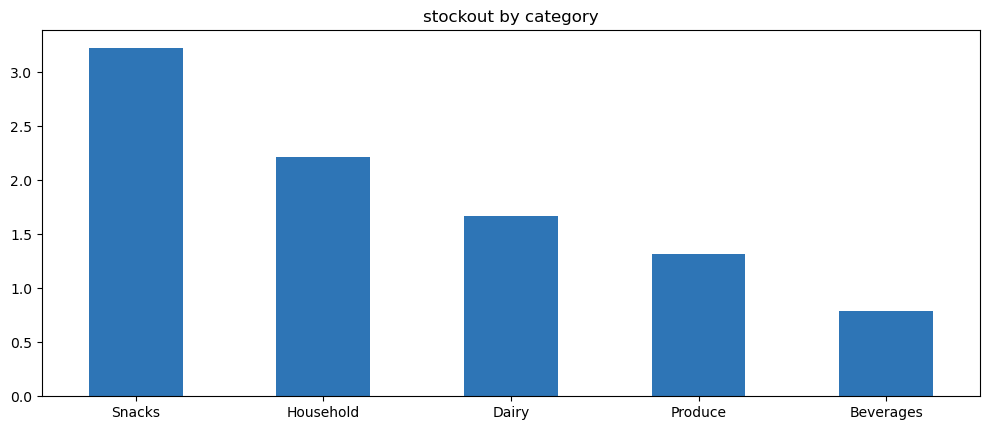

In [8]:
stockout_by_category = df.groupby("category_y")["stockout_flag"].mean().sort_values(ascending=False)
fig,ax = plt.subplots(figsize= (10,5))
(stockout_by_category * 100).plot(kind = 'bar', ax=ax, color="#2E75B6")
ax.set_title("stockout by category")
ax.set_ylabel('')
ax.set_xlabel('')
fig.tight_layout()
plt.xticks(rotation = 0)
fig.savefig("stockouts_per_category.png")

**Promotional effect**

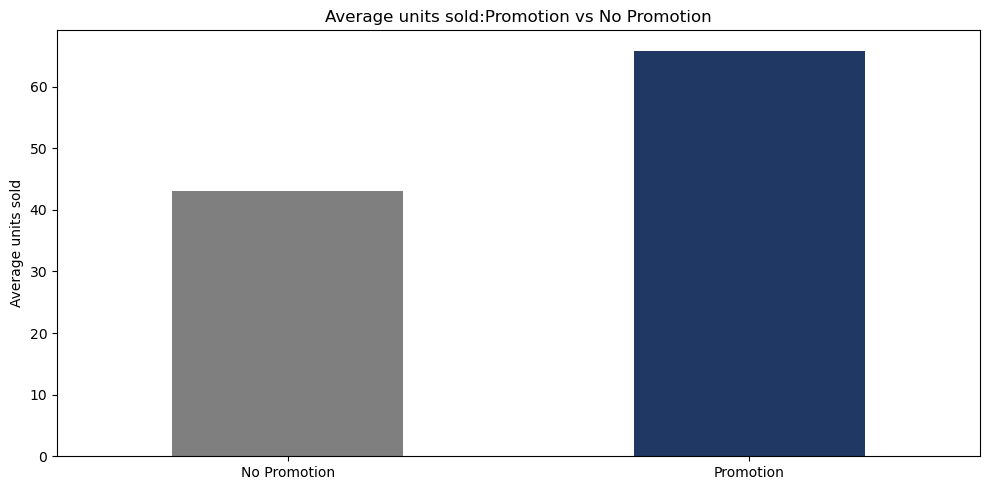

In [11]:
promo = df.groupby('promotion_flag')['units_sold'].mean()
promo.index = ['No Promotion','Promotion']

fig, ax = plt.subplots(figsize = (10,5))
promo.plot(kind = 'bar', ax=ax, color=["#7F7F7F", "#1F3864"])
ax.set_title('Average units sold:Promotion vs No Promotion')
ax.set_ylabel('Average units sold')
ax.set_xlabel('')
plt.xticks(rotation = 0)
fig.tight_layout()
fig.savefig('promotional_effect.png')

## EDA summary ##

**Average weekdays and weekend sales**

In [58]:
average_weekend_sales = df[df.is_weekend]['units_sold'].mean().round(0)
print(average_weekend_sales)

50.0


In [59]:
average_weekday_sales = df[~df.is_weekend]['units_sold'].mean().round(0)
print(average_weekday_sales)

42.0


**Date range**

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18275 entries, 0 to 18274
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              18275 non-null  object 
 1   product_name_x          18275 non-null  object 
 2   category_x              18275 non-null  object 
 3   units_sold              18275 non-null  int64  
 4   unit_price_x            18275 non-null  float64
 5   promotion_flag          18275 non-null  bool   
 6   stock_level_end_of_day  18275 non-null  float64
 7   stockout_flag           18275 non-null  bool   
 8   date                    18275 non-null  object 
 9   product_name_y          18275 non-null  object 
 10  category_y              18275 non-null  object 
 11  unit_cost               18275 non-null  float64
 12  unit_price_y            18275 non-null  float64
 13  lead_time_days          18275 non-null  int64  
 14  safety_stock_days       18275 non-null

In [28]:
##date is an object , first convert it into datetime 
df['date'] = pd.to_datetime(df['date'])

In [30]:
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")

Date Range: 2024-01-01 to 2025-12-31


**Total Revenue**

In [35]:
total = df['Revenue'].sum().round(0)
print(f"Total Revenue: {total} KSH")

Total Revenue: 105936670.0 KSH


**Overall stockout rate**

In [41]:
stockout_rate = df['stockout_flag'].mean()
print(f"Stockout rate: {stockout_rate:.1%}")

Stockout rate: 1.8%


**promotion lift**

In [43]:
promotion_lift = (promo['Promotion'] - promo['No Promotion'])/promo['No Promotion']
print(f"Promotion lift: {promotion_lift:.1%}")

Promotion lift: 53.2%


**top category by stockout**

In [55]:
stock_out_by_cat = df.groupby('category_y')['stockout_flag'].mean().sort_values(ascending = False)
print(stock_out_by_cat * 100)
print(stock_out_by_cat.index[0])

category_y
Snacks       3.228454
Household    2.216142
Dairy        1.668947
Produce      1.313269
Beverages    0.793434
Name: stockout_flag, dtype: float64
Snacks
